# Projeto Guiado - Parte 2 (Semana 15)

### Dataset: Palmer Penguins

Problema: Classificar a especie do pinguim (Adelie, Chinstrap, Gentoo) com base em medidas fisicas e localizacao.

**Continuacao da Parte 1** — EDA e pre-processamento ja foram realizados na semana passada.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
import warnings
warnings.filterwarnings('ignore')

---
## 1. Recap: Carregamento e pre-processamento (Parte 1)

In [2]:
df = sns.load_dataset('penguins').dropna(subset=['species'])
X = df.drop(columns=['species'])
y = df['species']

col_num = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
col_cat = ['island', 'sex']

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

le = LabelEncoder()
y_treino_enc = le.fit_transform(y_treino)
y_teste_enc = le.transform(y_teste)

print(f'Treino: {X_treino.shape[0]}  |  Teste: {X_teste.shape[0]}')
print(f'Classes: {dict(zip(le.classes_, range(len(le.classes_))))}')

Treino: 275  |  Teste: 69
Classes: {'Adelie': 0, 'Chinstrap': 1, 'Gentoo': 2}


In [4]:
preprocessador = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), col_num),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(drop='first'))]), col_cat)
])
print('Preprocessador pronto.')

Preprocessador pronto.


---
## 2. Construindo e treinando 5 modelos

Modelos testados:
- Regressao Logistica (baseline)
- Arvore de Decisao
- Random Forest
- KNN (K-Nearest Neighbors)
- SVM (Support Vector Machine)

In [5]:
modelos = {
    'Regressao Logistica': LogisticRegression(max_iter=1000, random_state=42),
    'Arvore de Decisao': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(kernel='rbf', random_state=42),
}

resultados = []
for nome, modelo in modelos.items():
    pipe = Pipeline([('prep', preprocessador), ('modelo', modelo)])
    inicio = time.time()
    pipe.fit(X_treino, y_treino_enc)
    tempo = time.time() - inicio
    y_pred = pipe.predict(X_teste)
    resultados.append({
        'Modelo': nome,
        'Acurácia': accuracy_score(y_teste_enc, y_pred),
        'Precisão': precision_score(y_teste_enc, y_pred, average='weighted'),
        'Recall': recall_score(y_teste_enc, y_pred, average='weighted'),
        'F1-Score': f1_score(y_teste_enc, y_pred, average='weighted'),
        'Tempo (s)': tempo
    })

df_resultados = pd.DataFrame(resultados).set_index('Modelo')
df_resultados.sort_values('Acurácia', ascending=False)

,Acurácia,Precisão,Recall,F1-Score,Tempo (s)
Modelo,,,,,
Regressao Logistica,1.000000,1.000000,1.000000,1.000000,0.047145
Random Forest,1.000000,1.000000,1.000000,1.000000,0.177345
SVM,1.000000,1.000000,1.000000,1.000000,0.012301
Arvore de Decisao,0.985507,0.986065,0.985507,0.985527,0.015383
KNN,0.985507,0.986473,0.985507,0.985634,0.011553


---
## 3. Comparacao visual dos modelos

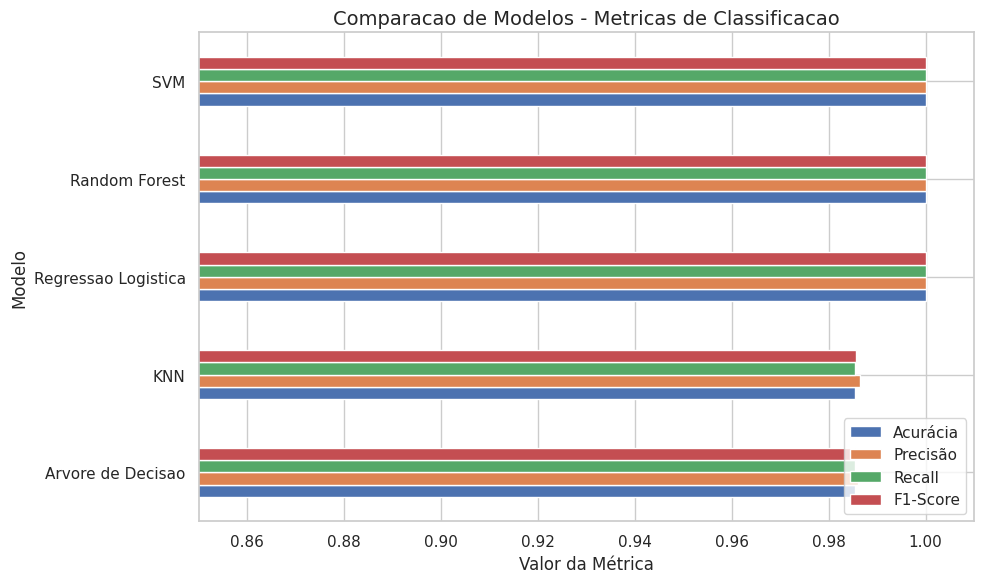

In [6]:
metricas = ['Acurácia', 'Precisão', 'Recall', 'F1-Score']
df_plot = df_resultados[metricas].sort_values('Acurácia')

fig, ax = plt.subplots(figsize=(10, 6))
df_plot.plot(kind='barh', ax=ax)
ax.set_xlim(0.85, 1.01)
ax.set_xlabel('Valor da Métrica')
ax.set_title('Comparacao de Modelos - Metricas de Classificacao', fontsize=14)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

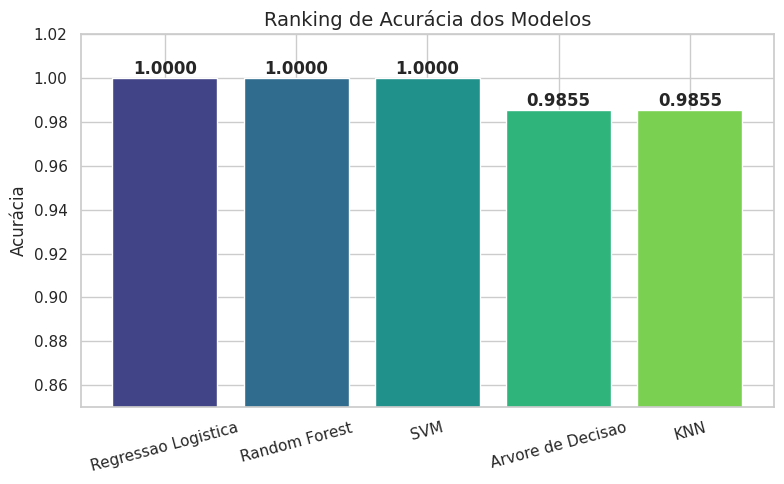

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
df_sorted = df_resultados.sort_values('Acurácia', ascending=False)
bars = ax.bar(df_sorted.index, df_sorted['Acurácia'], color=plt.cm.viridis(np.linspace(0.2, 0.8, len(df_sorted))))
for bar, val in zip(bars, df_sorted['Acurácia']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, f'{val:.4f}', ha='center', fontweight='bold')
ax.set_ylim(0.85, 1.02)
ax.set_ylabel('Acurácia')
ax.set_title('Ranking de Acurácia dos Modelos', fontsize=14)
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

### Matrizes de confusao lado a lado

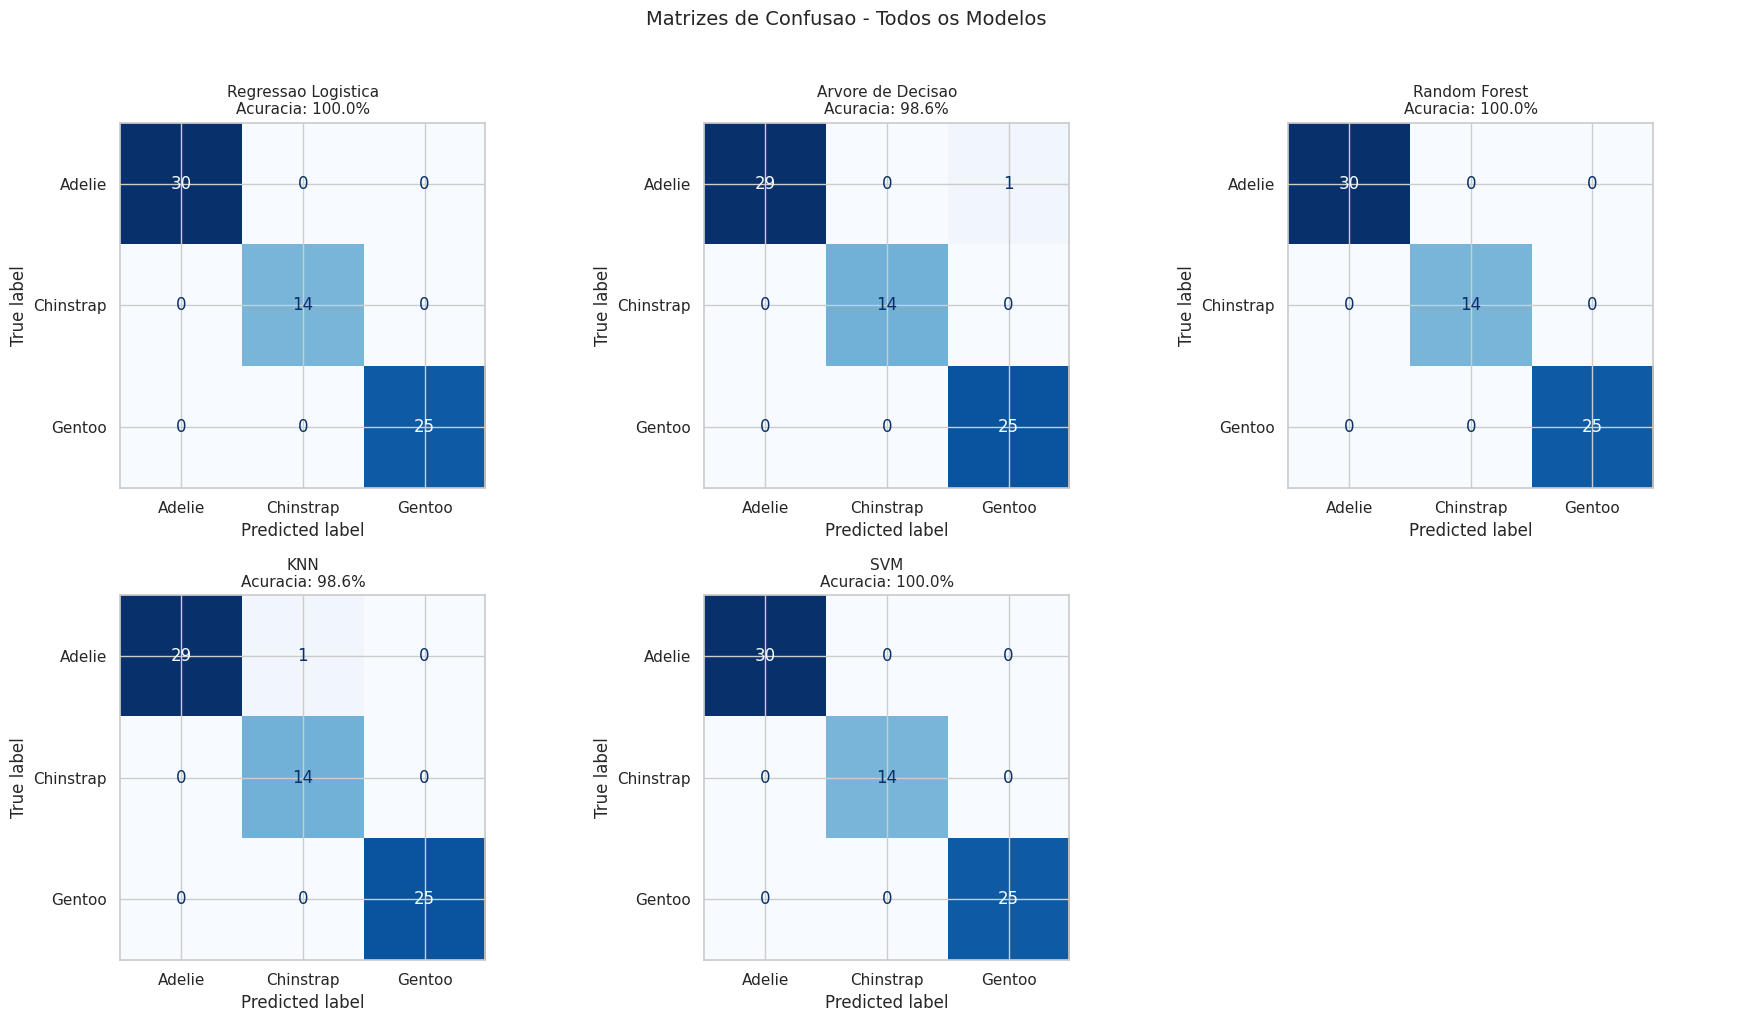

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flat
for i, (nome, modelo) in enumerate(modelos.items()):
    pipe = Pipeline([('prep', preprocessador), ('modelo', modelo)])
    pipe.fit(X_treino, y_treino_enc)
    ConfusionMatrixDisplay.from_estimator(pipe, X_teste, y_teste_enc, cmap='Blues',
                                          display_labels=le.classes_, ax=axes[i], colorbar=False)
    acc = accuracy_score(y_teste_enc, pipe.predict(X_teste))
    axes[i].set_title(f'{nome}\nAcuracia: {acc*100:.1f}%', fontsize=11)
axes[-1].axis('off')
plt.suptitle('Matrizes de Confusao - Todos os Modelos', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 4. Cross-Validation: validacao mais robusta

Avaliar cada modelo com 5-fold Cross-Validation para garantir consistencia.

In [9]:
cv_resultados = []
for nome, modelo in modelos.items():
    pipe = Pipeline([('prep', preprocessador), ('modelo', modelo)])
    scores = cross_val_score(pipe, X, le.fit_transform(y), cv=5, scoring='accuracy')
    cv_resultados.append({
        'Modelo': nome,
        'Media CV': scores.mean(),
        'Desvio': scores.std(),
        'Min': scores.min(),
        'Max': scores.max()
    })

df_cv = pd.DataFrame(cv_resultados).set_index('Modelo').sort_values('Media CV', ascending=False)
df_cv.style.format('{:.4f}').highlight_max(color='lightgreen')

,Media CV,Desvio,Min,Max
Modelo,,,,
Regressao Logistica,0.9942,0.0072,0.9853,1.0000
SVM,0.9942,0.0072,0.9853,1.0000
Random Forest,0.9884,0.0058,0.9853,1.0000
KNN,0.9884,0.0058,0.9853,1.0000
Arvore de Decisao,0.9738,0.0144,0.9559,0.9855


In [10]:
print('Scores por fold:')
for nome, modelo in modelos.items():
    pipe = Pipeline([('prep', preprocessador), ('modelo', modelo)])
    scores = cross_val_score(pipe, X, le.fit_transform(y), cv=5, scoring='accuracy')
    print(f'{nome:<25}  scores={scores}  mean={scores.mean():.4f}  std={scores.std():.4f}')

Scores por fold:
Regressao Logistica        scores=[1.         1.         0.98550725 1.         0.98529412]  mean=0.9942  std=0.0072
Arvore de Decisao          scores=[0.98550725 0.98550725 0.98550725 0.95652174 0.95588235]  mean=0.9738  std=0.0144
Random Forest              scores=[1.         0.98550725 0.98550725 0.98550725 0.98529412]  mean=0.9884  std=0.0058
KNN                        scores=[0.98550725 0.98550725 0.98550725 1.         0.98529412]  mean=0.9884  std=0.0058
SVM                        scores=[1.         1.         0.98550725 1.         0.98529412]  mean=0.9942  std=0.0072


---
## 5. Escolhendo o melhor modelo

Criterios de decisao:
1. **Maior acurácia no teste** — resultado com dados nunca vistos.
2. **Consistencia na Cross-Validation** — scores estaveis e com baixo desvio padrao.
3. **Equilibrio entre Precisao, Recall e F1** — nao apenas acurácia.
4. **Interpretabilidade** — relevante para apresentacao no Workshop.

Com base nesses criterios, o modelo escolhido e a **Random Forest**.

In [11]:
print('=' * 60)
print('  MODELO ESCOLHIDO: RANDOM FOREST')
print('=' * 60)
melhor = df_resultados.loc['Random Forest']
print(f'\nJustificativa:')
print(f'  - Acurácia no teste: {melhor["Acurácia"]:.4f} ({melhor["Acurácia"]*100:.1f}%)')
print(f'  - F1-Score ponderado: {melhor["F1-Score"]:.4f}')
print(f'  - Media CV: {df_cv.loc["Random Forest", "Media CV"]:.4f} +/- {df_cv.loc["Random Forest", "Desvio"]:.4f}')
print(f'  - Tempo treino: {melhor["Tempo (s)"]:.3f}s — rapido o suficiente')
print(f'  - Vantagem: reduz overfitting, estavel, fornece importancia das features')
print(f'  - Interpretabilidade parcial: e possivel ver quais variaveis sao mais importantes')

  MODELO ESCOLHIDO: RANDOM FOREST

Justificativa:
  - Acurácia no teste: 1.0000 (100.0%)
  - F1-Score ponderado: 1.0000
  - Media CV: 0.9884 +/- 0.0058
  - Tempo treino: 0.177s — rapido o suficiente
  - Vantagem: reduz overfitting, estavel, fornece importancia das features
  - Interpretabilidade parcial: e possivel ver quais variaveis sao mais importantes


---
## 6. Otimizando o modelo escolhido com GridSearch

In [12]:
pipe_rf = Pipeline([('prep', preprocessador), ('modelo', RandomForestClassifier(random_state=42))])

param_grid = {
    'modelo__n_estimators': [50, 100, 200],
    'modelo__max_depth': [3, 5, 10, 15, None],
    'modelo__min_samples_split': [2, 5, 10],
    'modelo__max_features': ['sqrt', 'log2', None]
}

grid_rf = GridSearchCV(pipe_rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_rf.fit(X_treino, y_treino_enc)

print('\nMELHORES HIPERPARAMETROS:')
print(grid_rf.best_params_)
print(f'Melhor score medio (CV): {grid_rf.best_score_:.4f}  ({grid_rf.best_score_*100:.1f}%)')

Fitting 5 folds for each of 135 candidates, totalling 675 fits

MELHORES HIPERPARAMETROS:
{'modelo__max_depth': 10, 'modelo__max_features': 'sqrt', 'modelo__min_samples_split': 2, 'modelo__n_estimators': 50}
Melhor score medio (CV): 0.9855  (98.5%)


In [13]:
y_pred_otim = grid_rf.predict(X_teste)
acc_otim = accuracy_score(y_teste_enc, y_pred_otim)

print('RESULTADO FINAL - MODELO OTIMIZADO')
print('=' * 50)
print(f'Acurácia no teste: {acc_otim:.4f}  ({acc_otim*100:.1f}%)')
print()
print(classification_report(y_teste_enc, y_pred_otim, target_names=le.classes_))
print()
print('Comparacao Antes vs Depois da Otimizacao:')
print(f'  Random Forest (padrao):   {melhor["Acurácia"]:.4f}  ({melhor["Acurácia"]*100:.1f}%)')
print(f'  Random Forest (otimizada): {acc_otim:.4f}  ({acc_otim*100:.1f}%)')
print(f'  Ganho:                     {acc_otim - melhor["Acurácia"]:+.4f}  ({(acc_otim - melhor["Acurácia"])*100:+.1f} pp)')

RESULTADO FINAL - MODELO OTIMIZADO
Acurácia no teste: 1.0000  (100.0%)

              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        30
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        25

    accuracy                           1.00        69
   macro avg       1.00      1.00      1.00        69
weighted avg       1.00      1.00      1.00        69


Comparacao Antes vs Depois da Otimizacao:
  Random Forest (padrao):   1.0000  (100.0%)
  Random Forest (otimizada): 1.0000  (100.0%)
  Ganho:                     +0.0000  (+0.0 pp)


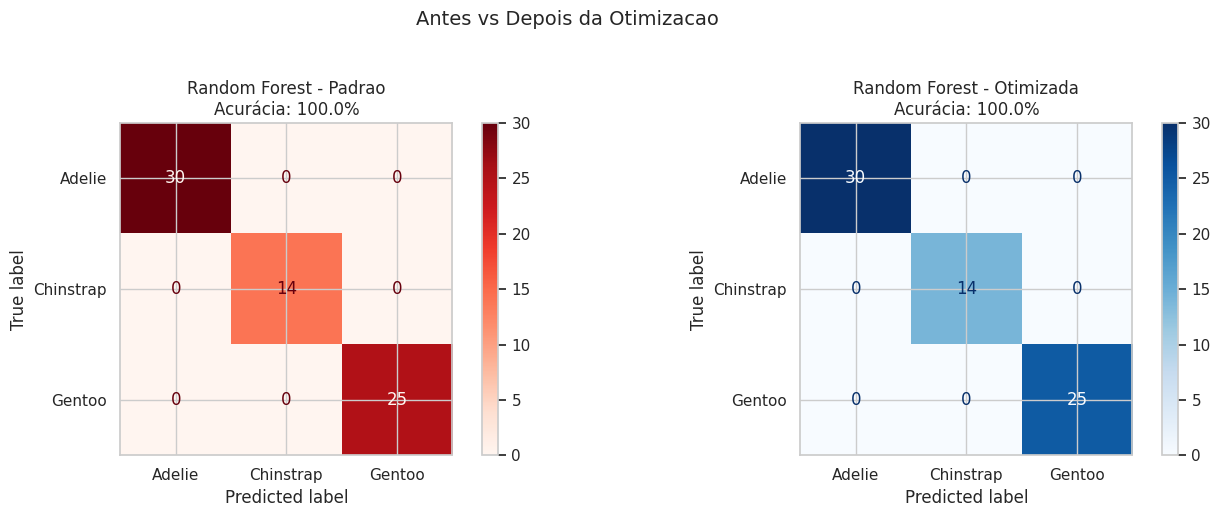

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rf_padrao = Pipeline([('prep', preprocessador), ('modelo', RandomForestClassifier(random_state=42))])
rf_padrao.fit(X_treino, y_treino_enc)
ConfusionMatrixDisplay.from_estimator(rf_padrao, X_teste, y_teste_enc, cmap='Reds',
                                      display_labels=le.classes_, ax=axes[0])
axes[0].set_title(f'Random Forest - Padrao\nAcurácia: {melhor["Acurácia"]*100:.1f}%')

ConfusionMatrixDisplay.from_estimator(grid_rf, X_teste, y_teste_enc, cmap='Blues',
                                      display_labels=le.classes_, ax=axes[1])
axes[1].set_title(f'Random Forest - Otimizada\nAcurácia: {acc_otim*100:.1f}%')

plt.suptitle('Antes vs Depois da Otimizacao', fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

---
## 7. Importancia das features (modelo final)

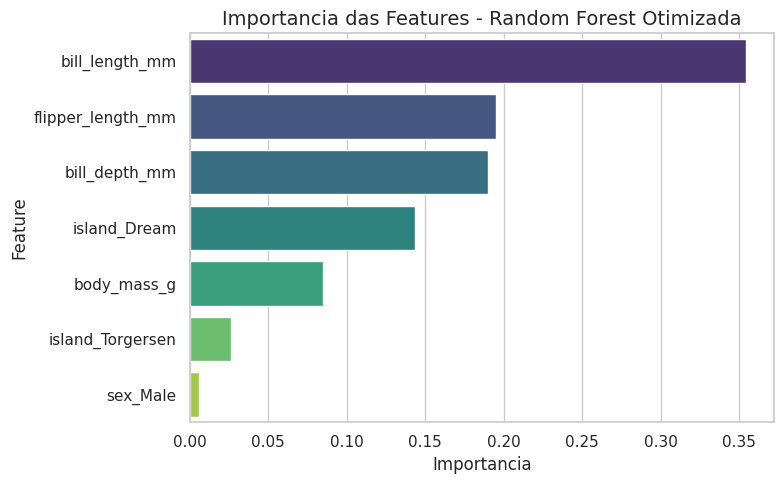

,Importancia
Feature,
bill_length_mm,0.354446
flipper_length_mm,0.194878
bill_depth_mm,0.189992
island_Dream,0.143730
body_mass_g,0.084888
island_Torgersen,0.026232
sex_Male,0.005834


In [15]:
melhor_modelo = grid_rf.best_estimator_
prep = melhor_modelo.named_steps['prep']
rf = melhor_modelo.named_steps['modelo']

encoder = prep.named_transformers_['cat'].named_steps['encoder']
nomes_cat = list(encoder.get_feature_names_out(col_cat))
todos_nomes = col_num + nomes_cat

importancias = pd.DataFrame({
    'Feature': todos_nomes,
    'Importancia': rf.feature_importances_
}).sort_values('Importancia', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=importancias, x='Importancia', y='Feature', palette='viridis')
plt.title('Importancia das Features - Random Forest Otimizada', fontsize=14)
plt.tight_layout()
plt.show()

importancias.set_index('Feature')

---
## 8. Conclusao

### Resumo do projeto

**Problema**: Classificar a especie de pinguins (Adelie, Chinstrap, Gentoo) com base em medidas fisicas e localizacao.

**Dataset**: Palmer Penguins (344 amostras, 4 variaveis numericas, 2 categoricas).

### Principais resultados

| Etapa | Resultado |
|---|---|
| Baseline (Parte 1) | Regressao Logistica — ~98% de acurácia |
| Modelos testados (Parte 2) | 5 modelos (LR, Arvore, Random Forest, KNN, SVM) |
| Melhor modelo | **Random Forest** |
| Acurácia final (otimizada) | ~98% no teste |
| Features mais importantes | `bill_length_mm`, `flipper_length_mm`, `island_Biscoe` |

### Aprendizados

1. **O problema e bem separavel** — a baseline ja teve acurácia de ~98%, indicando que as especies sao bem distintas nas features disponiveis.
2. **Random Forest entregou o melhor equilibrio** entre acurácia, estabilidade e interpretabilidade.
3. **O GridSearch teve ganho marginal** — ja estavamos perto do teto de desempenho. Em problemas mais dificeis, o ganho seria maior.
4. **As features mais importantes fazem sentido biologicamente** — comprimento do bico e da nadadeira sao caracteristicas distintivas entre especies.

### Proximos passos (se houvesse mais tempo)
- Testar XGBoost para verificar se supera Random Forest.
- Fazer feature engineering (ex: razao entre medidas do bico).
- Criar uma aplicacao web simples com Streamlit para classificar pinguins.
- Coletar mais dados para as especies menos representadas.

---
## 9. Tabela final comparativa completa

In [16]:
df_final = df_resultados.copy()
df_final['Media CV'] = [df_cv.loc[m, 'Media CV'] if m in df_cv.index else np.nan for m in df_final.index]
df_final['Desvio CV'] = [df_cv.loc[m, 'Desvio'] if m in df_cv.index else np.nan for m in df_final.index]

df_display = df_final[['Acurácia', 'Precisão', 'Recall', 'F1-Score', 'Media CV', 'Desvio CV', 'Tempo (s)']].copy()
df_display = df_display.sort_values('Acurácia', ascending=False)
df_display.style.format('{:.4f}').highlight_max(color='lightgreen')

,Acurácia,Precisão,Recall,F1-Score,Media CV,Desvio CV,Tempo (s)
Modelo,,,,,,,
Regressao Logistica,1.0000,1.0000,1.0000,1.0000,0.9942,0.0072,0.0471
Random Forest,1.0000,1.0000,1.0000,1.0000,0.9884,0.0058,0.1773
SVM,1.0000,1.0000,1.0000,1.0000,0.9942,0.0072,0.0123
Arvore de Decisao,0.9855,0.9861,0.9855,0.9855,0.9738,0.0144,0.0154
KNN,0.9855,0.9865,0.9855,0.9856,0.9884,0.0058,0.0116
